## *Operation Note*

*Jupyter NotebookからWebアプリケーション等のチェックを機械化する方法として、Playwright https://playwright.dev/python/ を使う方法があります。このNotebookでは構築したEtherpadの動作確認を行なってみます。*

# Playwrightの準備

本イメージにてPlaywrightを利用可能にするには、一度 `playwright install` を実行する必要があります。

In [1]:
!playwright install

Playwright Host validation warning: 
╔══════════════════════════════════════════════════════╗
║ Host system is missing dependencies to run browsers. ║
║ Missing libraries:                                   ║
║     libgtk-4.so.1                                    ║
║     libgraphene-1.0.so.0                             ║
║     libwoff2dec.so.1.0.2                             ║
║     libevent-2.1.so.7                                ║
║     libgstgl-1.0.so.0                                ║
║     libgstcodecparsers-1.0.so.0                      ║
║     libavif.so.16                                    ║
║     libharfbuzz-icu.so.0                             ║
║     libsecret-1.so.0                                 ║
║     libhyphen.so.0                                   ║
║     libmanette-0.2.so.0                              ║
║     libGLESv2.so.2                                   ║
╚══════════════════════════════════════════════════════╝
    at validateDependenciesLinux (/opt/conda/lib/py

# 接続先確認

`service_url` はAnsibleから取得します。

In [2]:
%env ANSIBLE_INVENTORY=./hosts
target_group = 'epweave0001'
!ansible -m ping {target_group}

env: ANSIBLE_INVENTORY=./hosts
57.183.73.254 | SUCCESS => {
    "changed": false,
    "ping": "pong"
}


In [3]:
ping_result = !ansible -m ping {target_group}
ping_success_result = [line for line in ping_result if 'SUCCESS' in line]
assert len(ping_success_result) > 0, ping_success_result
ip_address = ping_success_result[0].split()[0]
service_url = f'http://{ip_address}:9001/'
service_url

'http://57.183.73.254:9001/'

このJupyter Notebookのアクセス元IPアドレスは以下となる。

> IPアドレスの取得に https://ifconfig.co サービスを使用します。

In [4]:
import requests
resp = requests.get('https://ifconfig.co/json')
resp.raise_for_status()
print(resp.json()['ip'])

18.179.171.165


ep_weaveのSecurity Group(構築Notebook参照)を開き、上記IPからTCP 9001のアクセスを許可しておくこと。

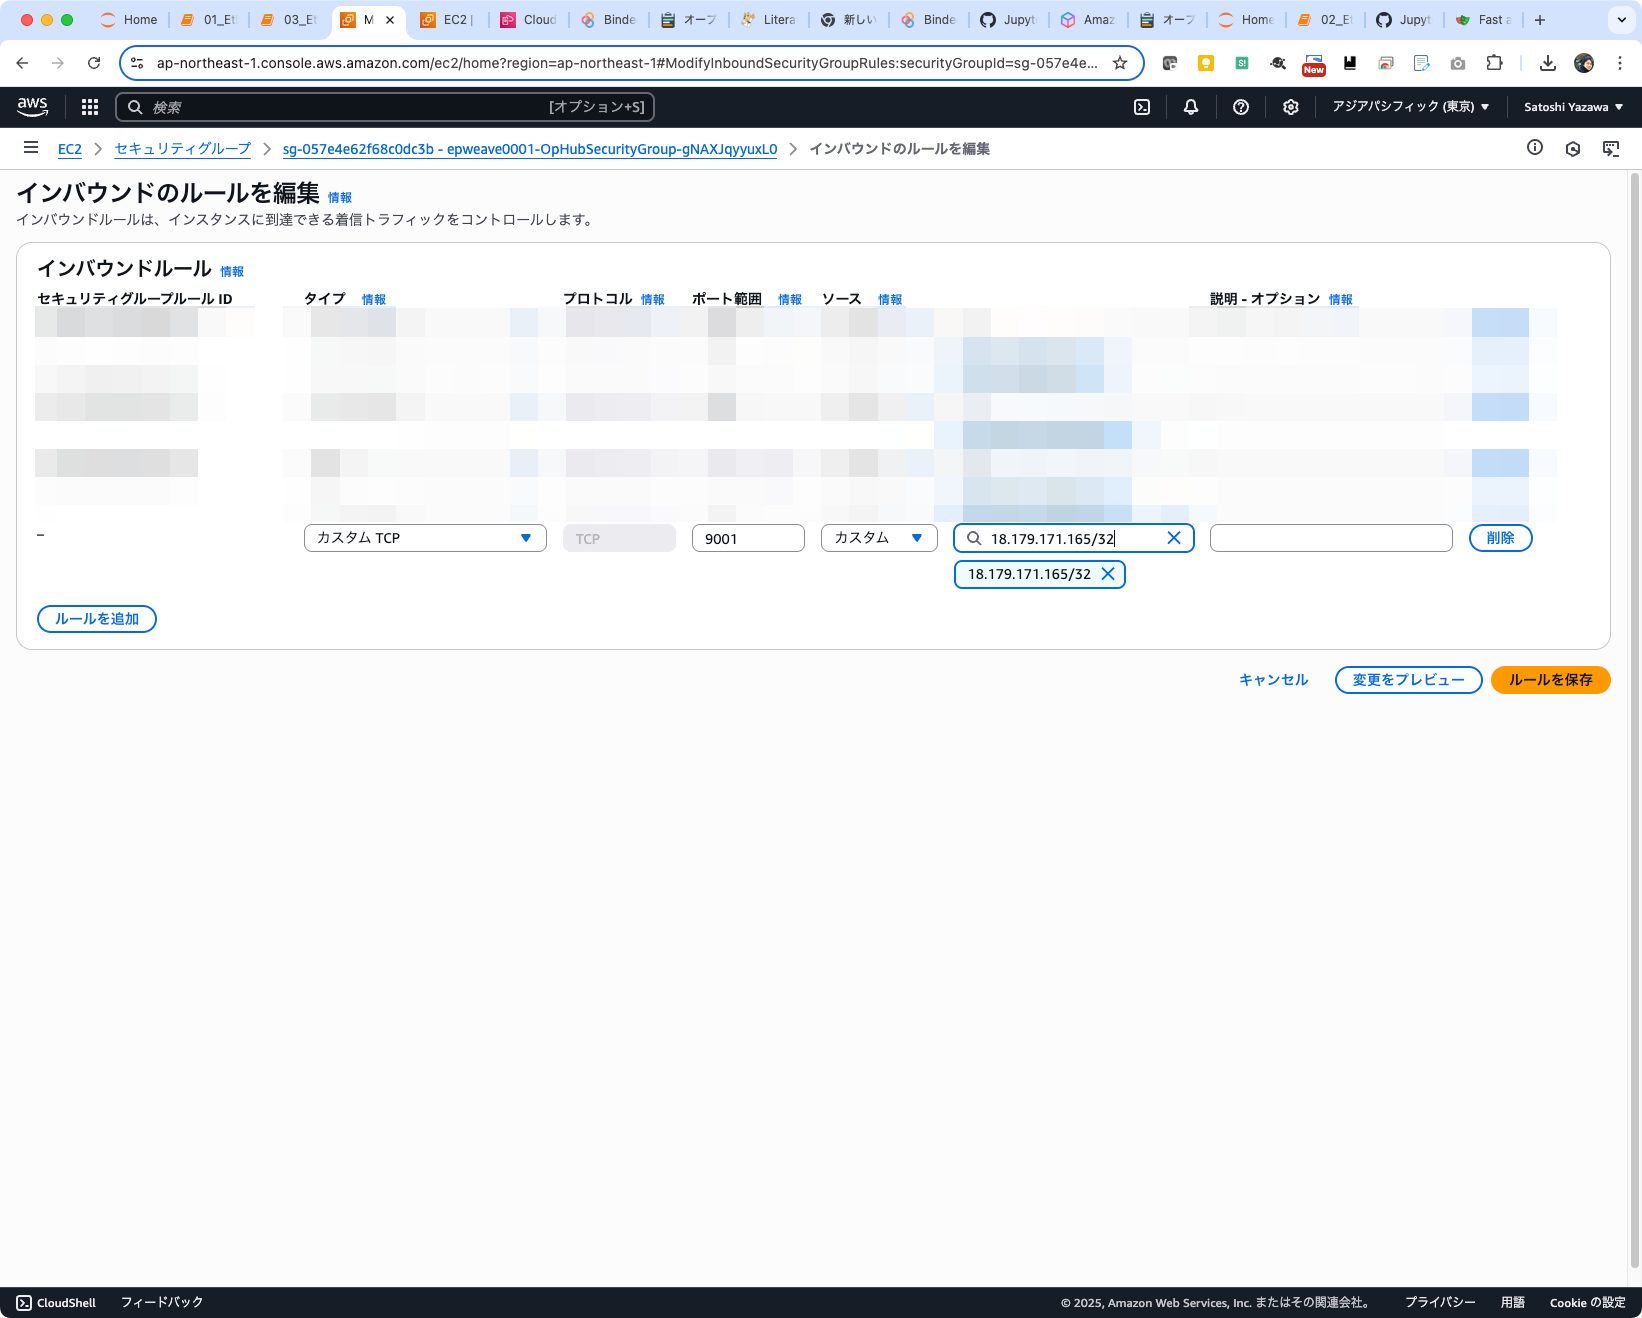

# ep_weaveの動作確認

Playwrightを通じてep_weaveの簡単な動作確認をする例です。

In [5]:
import os
import tempfile

work_dir = tempfile.mkdtemp()
screenshot_path = os.path.join(work_dir, 'screenshot.png')
work_dir

'/tmp/tmp1rp4f4ad'

ダッシュボードを開きます。開けない場合、Security Groupに、このIPアドレスから 9001番ポートへのアクセスを許可しているか確認してください。(1つ前のSection参照)

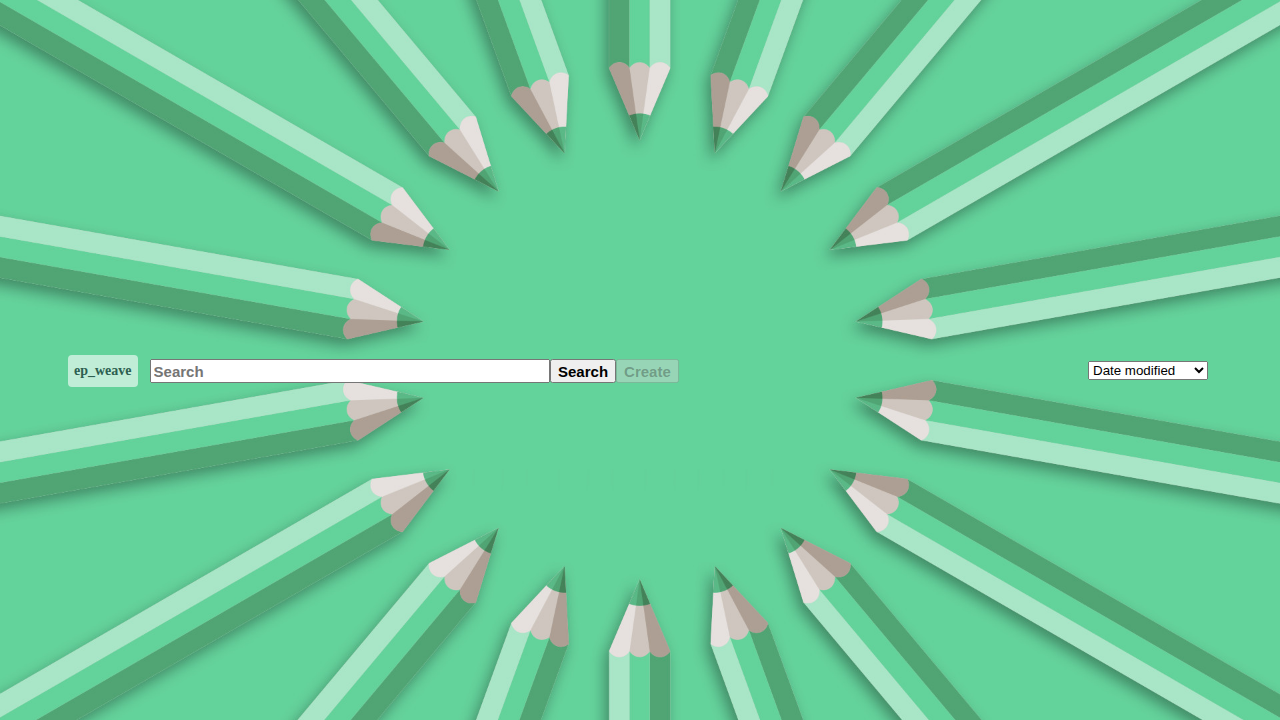

In [6]:
from playwright.async_api import async_playwright, expect
from IPython.display import Image

playwright = await async_playwright().start()
browser = await playwright.chromium.launch()
os.makedirs(os.path.join(work_dir, "videos/"))
context = await browser.new_context(record_video_dir=os.path.join(work_dir, "videos/"))
page = await context.new_page()
await page.goto(service_url)

await expect(page.locator('input.hashview-search-box')).to_be_visible()

await page.screenshot(path=screenshot_path)
Image(filename=screenshot_path)

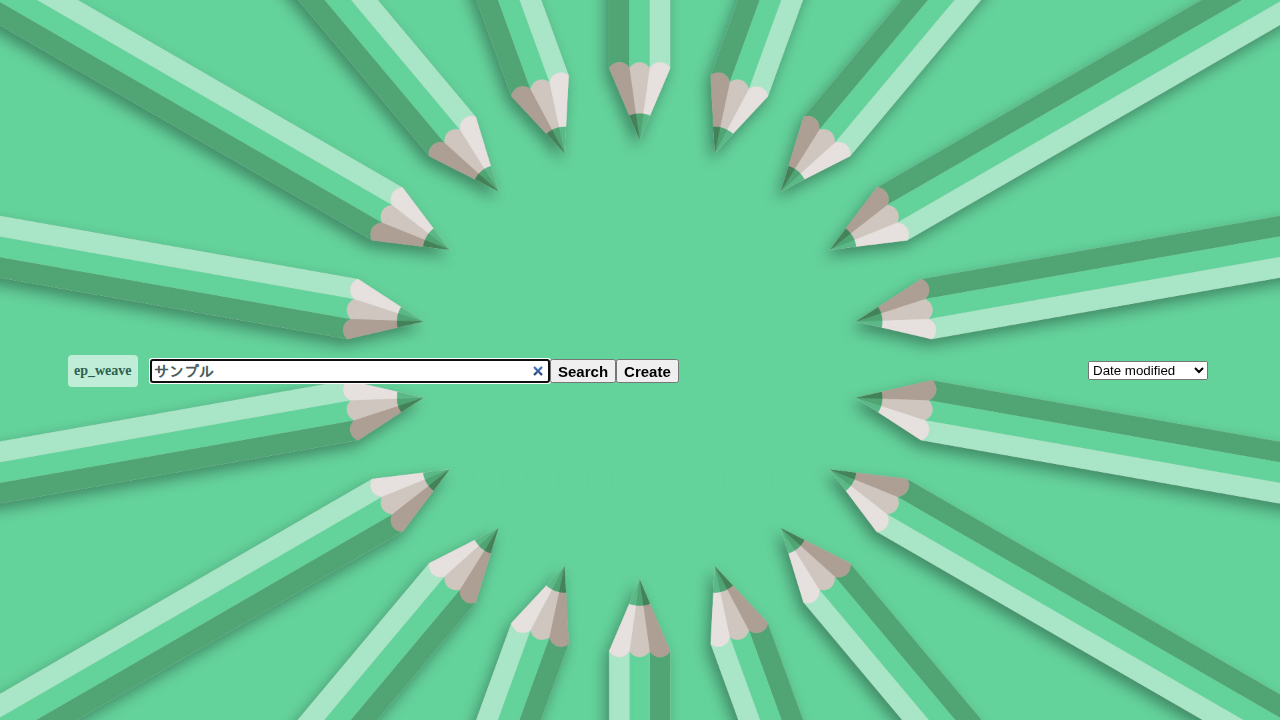

In [7]:
await page.locator('input.hashview-search-box').fill('サンプル')
await page.keyboard.press('Enter')

await page.screenshot(path=screenshot_path)
Image(filename=screenshot_path)

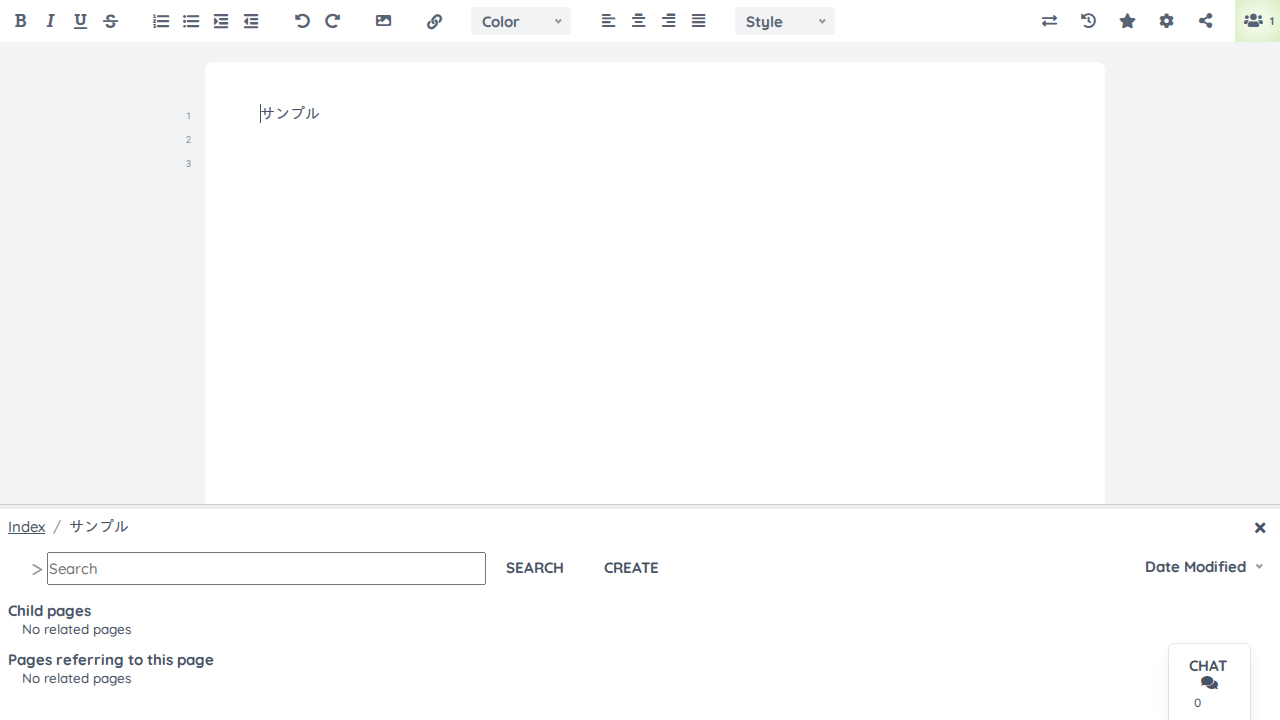

In [8]:
async with context.expect_page() as new_page_info:
    await page.locator('//button[text()="Create"]').click()

editor_page = await new_page_info.value

await expect(editor_page.locator('#editbar')).to_be_visible(timeout=30000)

await editor_page.screenshot(path=screenshot_path)
Image(filename=screenshot_path)

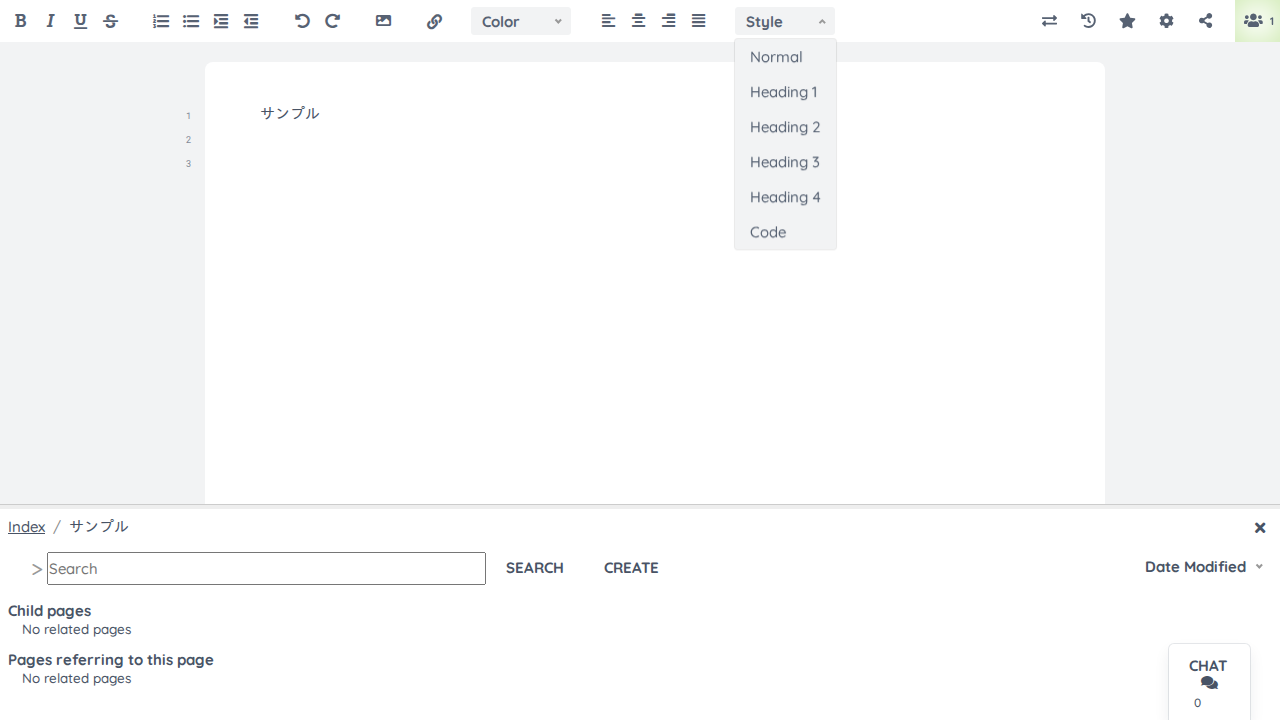

In [9]:
await editor_page.locator('//span[text()="Style"]').click()

await expect(editor_page.locator('//li[text()="Heading 1"]')).to_be_enabled()

await editor_page.screenshot(path=screenshot_path)
Image(filename=screenshot_path)

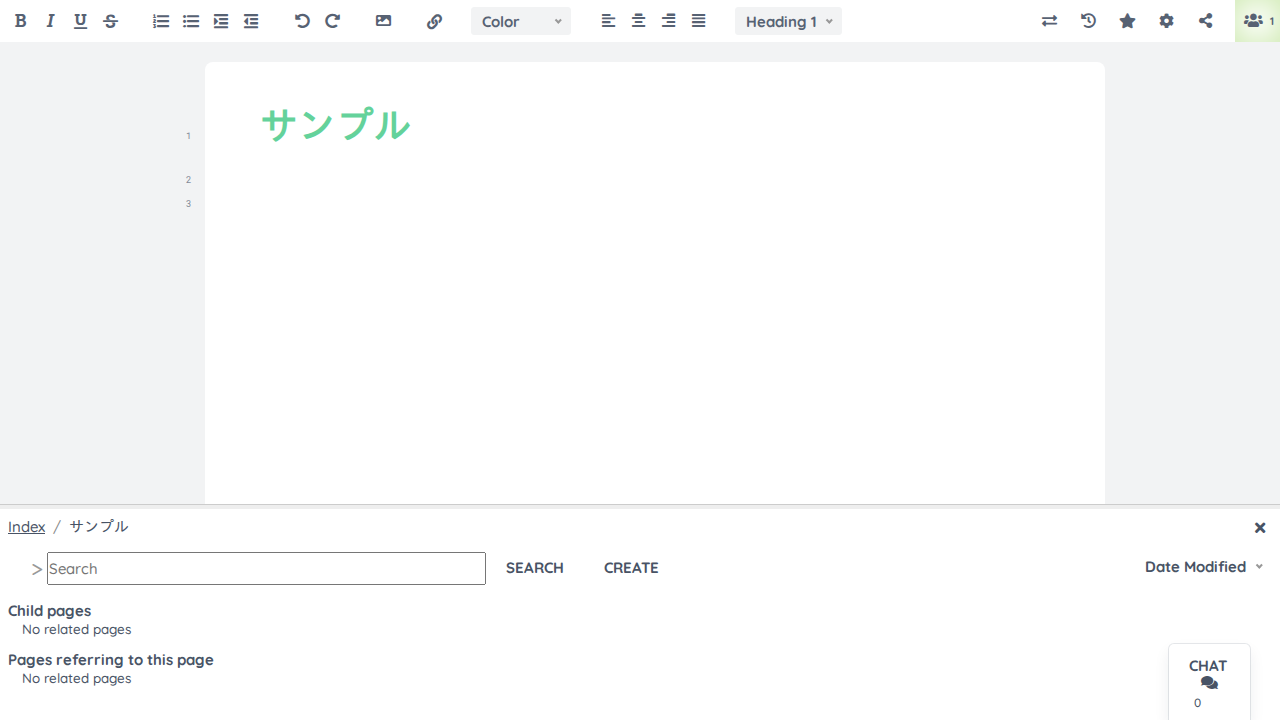

In [10]:
import asyncio

await editor_page.locator('//li[text()="Heading 1"]').click()

await asyncio.sleep(5)

await editor_page.screenshot(path=screenshot_path)
Image(filename=screenshot_path)

# 実行結果収集

動作確認完了。

動作確認中の動画は以下のセルで取得できます。

In [11]:
await page.close()
await editor_page.close()
await context.close()
await browser.close()

video_path = './video'
!mkdir -p {video_path}

index_video_path = await page.video.path()
editor_video_path = await editor_page.video.path()
!mv {index_video_path} {video_path}/index.webm
!mv {editor_video_path} {video_path}/editor.webm
!ls -la {video_path}

total 420
drwxr-xr-x 3 ohadmin users   4096 Jun 18 03:01 .
drwxr-xr-x 6 ohadmin  1001   4096 Jun 18 03:01 ..
drwxr-xr-x 2 ohadmin users   4096 Jun 18 02:59 .ipynb_checkpoints
-rw-r--r-- 1 ohadmin users 107860 Jun 18 03:01 editor.webm
-rw-r--r-- 1 ohadmin users 306944 Jun 18 03:01 index.webm


# 後始末

一時ファイルを削除する...

In [12]:
!rm -fr {work_dir}